In [107]:
import os, random, warnings, csv, json as _json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [108]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [109]:
def seed_everything(seed=7):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(7)
print('Seed = 7')

Seed = 7


In [110]:
TRAIN_DATA_ROOT = os.path.expanduser('~/Desktop/george/rocks_spectral_224')
NEW_DATA_ROOT   = os.path.expanduser('~/for_test_data_spectral_224')
OOD_FOLDER      = os.path.join(NEW_DATA_ROOT, 'Dunite-Ecologite_2Rocks_1-83Hz')
RESULTS_DIR     = 'results_rock_classifier_multisource'
ARCH            = 'resnet18'
USE_STRONG_AUG  = True
FREEZE_BACKBONE = False
EPOCHS          = 20
LR              = 1e-4
WEIGHT_DECAY    = 1e-4
BATCH_SIZE      = 64
TEST_SPLIT      = 0.25
OOD_FPR         = 0.05
CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#59a14f']
OOD_COLOR    = '#e15759'
VALID_EXT    = ('.jpg', '.jpeg', '.bmp', '.png')
DIR_TRAIN = os.path.join(RESULTS_DIR, 'training')
DIR_EVAL  = os.path.join(RESULTS_DIR, 'evaluation_known_rocks')
DIR_OOD   = os.path.join(RESULTS_DIR, 'ood_calibration')
DIR_INF   = os.path.join(RESULTS_DIR, 'inference_dunite')
DIR_CAM   = os.path.join(RESULTS_DIR, 'gradcam')
DIR_CMP   = os.path.join(RESULTS_DIR, 'comparison')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_EVAL, DIR_OOD, DIR_INF, DIR_CAM, DIR_CMP]:
    os.makedirs(d, exist_ok=True)
MODEL_183 = os.path.join(RESULTS_DIR, 'rock_classifier_resnet18_multisource_1-83Hz.pth')
MODEL_510 = os.path.join(RESULTS_DIR, 'rock_classifier_resnet18_multisource_5-10Hz.pth')
_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')
print('Config ready.')

Config ready.


In [111]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform_strong = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])
train_transform_standard = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])
active_train_transform = (
    train_transform_strong if USE_STRONG_AUG else train_transform_standard)
print(f'Transforms ready  [{"STRONG" if USE_STRONG_AUG else "standard"} aug]')

Transforms ready  [STRONG aug]


In [112]:
class SpectralImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

class UnlabelledDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, os.path.basename(self.paths[idx])

print('Dataset classes ready.')

Dataset classes ready.


In [113]:
def build_model(n_classes, arch='resnet18', freeze_backbone=False):
    if arch == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'resnet34':
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    else:
        raise ValueError(f'Unknown arch: {arch}')
    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith('fc'): p.requires_grad_(False)
    return model

class GradCAM:
    def __init__(self, model):
        self.model = model; self._acts = self._grads = None
        target = model.layer4[-1]
        self._fh = target.register_forward_hook(
            lambda m,i,o: setattr(self,'_acts',o.detach()))
        self._bh = target.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'_grads',go[0].detach()))
    def generate(self, img_t, class_idx=None):
        self.model.eval()
        out = self.model(img_t)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0,class_idx] = 1.0
        out.backward(gradient=oh)
        w   = self._grads.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((w*self._acts).sum(dim=1,keepdim=True))
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam/cam.max()
        cam = F.interpolate(cam,(224,224),mode='bilinear',align_corners=False)
        return cam.squeeze().cpu().numpy(), class_idx
    def remove(self): self._fh.remove(); self._bh.remove()

_m = build_model(3, ARCH, FREEZE_BACKBONE)
n_tr = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'{ARCH} | trainable params: {n_tr:,} | freeze_backbone={FREEZE_BACKBONE}')
del _m

resnet18 | trainable params: 11,178,051 | freeze_backbone=False


In [ ]:
# MULTI-SOURCE DATA COLLECTION
# Each class gets a list of folder paths — all are pooled before splitting.

def files_from_folder(folder):
    """Return sorted list of image file paths in a folder."""
    if not os.path.isdir(folder):
        raise FileNotFoundError(f'Folder not found: {folder}')
    return sorted([
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(VALID_EXT)
    ])


def collect_from_folders(class_folder_map, label):
    """
    class_folder_map: dict {class_name: [folder1, folder2, ...]}
    Returns (paths, labels, source_tags) where source_tags tracks
    which folder each image came from (for analysis).
    """
    paths, labels_out, source_tags = [], [], []
    for cls_name, folders in class_folder_map.items():
        cls_label = CLASS_NAMES.index(cls_name)
        for folder in folders:
            imgs = files_from_folder(folder)
            folder_tag = os.path.basename(folder)
            paths.extend(imgs)
            labels_out.extend([cls_label] * len(imgs))
            source_tags.extend([folder_tag] * len(imgs))
            print(f'  [{cls_name}] {folder_tag}: {len(imgs)} images')
    return paths, labels_out, source_tags



sources_183 = {
    'S10Granite': [
        os.path.join(TRAIN_DATA_ROOT, 'S10Granite_1-83Hz_Spectral'),
        os.path.join(NEW_DATA_ROOT,   'Gneis_1-83Hz'),
        os.path.join(NEW_DATA_ROOT,   'Granite_3SamplesPhilipp_1-83Hz_1'),
        os.path.join(NEW_DATA_ROOT,   'Granite_3SamplesPhilipp_1-83Hz_2'),
    ],
    'Holstein_Sandstone': [
        os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_1-83Hz_Spectral'),
        os.path.join(NEW_DATA_ROOT,   'SandstoneNew_1-83Hz'),
    ],
    'Leitendorf_Limestone': [
        os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_1-83Hz_Spectral'),
        os.path.join(NEW_DATA_ROOT,   'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz'),
        os.path.join(NEW_DATA_ROOT,   'Limestone_Rax_1-83Hz_1'),
        os.path.join(NEW_DATA_ROOT,   'Limestone_Rax_1-83Hz_2'),
    ],
}
sources_510 = {
    'S10Granite': [
        os.path.join(TRAIN_DATA_ROOT, 'S10Granite_5-10Hz_Spectral'),
    ],
    'Holstein_Sandstone': [
        os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_5-10Hz_Spectral'),
    ],
    'Leitendorf_Limestone': [
        os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_5-10Hz_Spectral'),
        os.path.join(NEW_DATA_ROOT,   'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz'),
    ],
}
print('=== Collecting 1.83 Hz multi-source data ===')
paths_183, labels_183, tags_183 = collect_from_folders(sources_183, None)
print(f'  TOTAL 1.83 Hz: {len(paths_183)} images')
print('\n=== Collecting 5.10 Hz multi-source data ===')
paths_510, labels_510, tags_510 = collect_from_folders(sources_510, None)
print(f'  TOTAL 5.10 Hz: {len(paths_510)} images')


=== Collecting 1.83 Hz multi-source data ===
  [S10Granite] S10Granite_1-83Hz_Spectral: 4003 images
  [S10Granite] Gneis_1-83Hz: 500 images
  [S10Granite] Granite_3SamplesPhilipp_1-83Hz_1: 1000 images
  [S10Granite] Granite_3SamplesPhilipp_1-83Hz_2: 490 images
  [Holstein_Sandstone] Holstein_Sandstone_1-83Hz_Spectral: 4000 images
  [Holstein_Sandstone] SandstoneNew_1-83Hz: 21 images
  [Leitendorf_Limestone] Leitendorf_Limestone_1-83Hz_Spectral: 4076 images
  [Leitendorf_Limestone] Limestone_CalcsilicaContaminated_U9_U3_1-83Hz: 1000 images
  [Leitendorf_Limestone] Limestone_Rax_1-83Hz_1: 25 images
  [Leitendorf_Limestone] Limestone_Rax_1-83Hz_2: 20 images
  TOTAL 1.83 Hz: 15135 images

=== Collecting 5.10 Hz multi-source data ===
  [S10Granite] S10Granite_5-10Hz_Spectral: 4155 images
  [Holstein_Sandstone] Holstein_Sandstone_5-10Hz_Spectral: 4000 images
  [Leitendorf_Limestone] Leitendorf_Limestone_5-10Hz_Spectral: 4035 images
  [Leitendorf_Limestone] Limestone_CalcsilicaContaminated_U9

[SAVED] results_rock_classifier_multisource/training/TR-00_dataset_composition__multisource.png


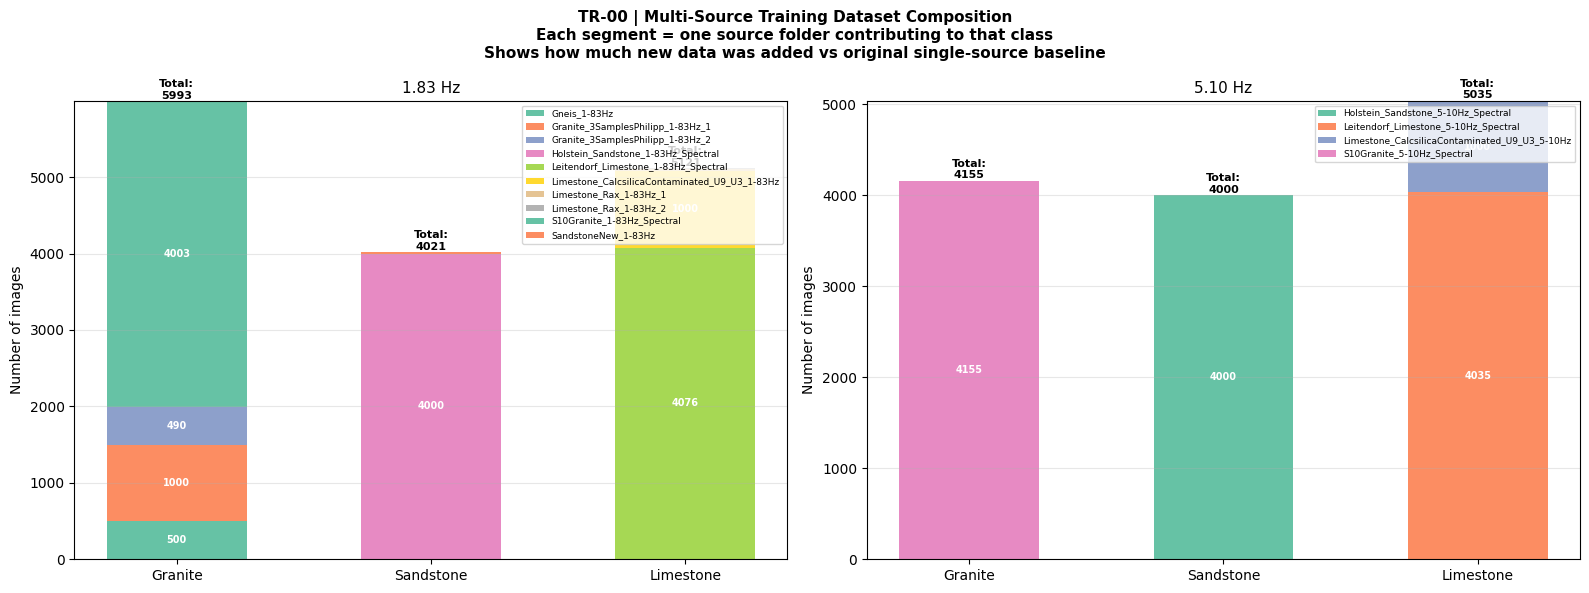

In [115]:
# TR-00  Dataset composition: how many images per source per class
# What it shows: the new training dataset broken down by source folder.
# Each coloured segment = one source folder. Shows the class balance
# and how much each new source contributes compared to the original.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'TR-00 | Multi-Source Training Dataset Composition\n'
    'Each segment = one source folder contributing to that class\n'
    'Shows how much new data was added vs original single-source baseline',
    fontsize=11, fontweight='bold')

for ax, (tag, paths, labels, tags) in zip(axes, [
    ('1.83 Hz', paths_183, labels_183, tags_183),
    ('5.10 Hz', paths_510, labels_510, tags_510)
]):
    class_source_counts = {cls: {} for cls in CLASS_NAMES}
    for p, l, t in zip(paths, labels, tags):
        cls = CLASS_NAMES[l]
        class_source_counts[cls][t] = class_source_counts[cls].get(t, 0) + 1

    x     = np.arange(len(CLASS_NAMES))
    cmap  = plt.cm.Set2(np.linspace(0, 1, 8))
    bot   = np.zeros(len(CLASS_NAMES))
    all_sources = sorted(set(tags))
    ci    = 0
    for src in all_sources:
        vals = [class_source_counts[cls].get(src, 0) for cls in CLASS_NAMES]
        if sum(vals) == 0: continue
        bars = ax.bar(x, vals, bottom=bot, color=cmap[ci % 8],
                       label=src, width=0.55)
        for xi, (v, b) in enumerate(zip(vals, bot)):
            if v > 50:
                ax.text(xi, b+v/2, str(v), ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        bot += np.array(vals)
        ci  += 1
    totals = [sum(class_source_counts[c].values()) for c in CLASS_NAMES]
    for xi, tot in enumerate(totals):
        ax.text(xi, tot+30, f'Total:\n{tot}', ha='center', fontsize=8,
                fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES)
    ax.set_ylabel('Number of images'); ax.set_title(f'{tag}', fontsize=11)
    ax.legend(fontsize=6.5, loc='upper right', ncol=1)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_TRAIN,
    'TR-00_dataset_composition__multisource.png',
    'Training dataset composition by source folder for each class. '
    'Shows original vs new sources and image counts per class.')
plt.show()

In [116]:
# STRATIFIED TRAIN/TEST SPLIT
# Stratify by label so each class is proportionally represented.
# Every source folder contributes to both train and test.

p_tr_183, p_te_183, l_tr_183, l_te_183 = train_test_split(
    paths_183, labels_183, test_size=TEST_SPLIT,
    stratify=labels_183, random_state=7)

p_tr_510, p_te_510, l_tr_510, l_te_510 = train_test_split(
    paths_510, labels_510, test_size=TEST_SPLIT,
    stratify=labels_510, random_state=7)

train_ds_183 = SpectralImageDataset(p_tr_183, l_tr_183, active_train_transform)
test_ds_183  = SpectralImageDataset(p_te_183, l_te_183, eval_transform)
train_ds_510 = SpectralImageDataset(p_tr_510, l_tr_510, active_train_transform)
test_ds_510  = SpectralImageDataset(p_te_510, l_te_510, eval_transform)

print(f'1.83 Hz  train={len(p_tr_183)}  test={len(p_te_183)}')
print(f'5.10 Hz  train={len(p_tr_510)}  test={len(p_te_510)}')

1.83 Hz  train=11351  test=3784
5.10 Hz  train=9892  test=3298


In [117]:
def train_and_save(train_ds, test_ds, model_save_path, speed_tag):
    if os.path.exists(model_save_path):
        print(f'[SKIP] {os.path.basename(model_save_path)} exists. Delete to retrain.')
        return None

    seed_everything(7)
    print(f'\nTraining [{speed_tag}]  n_train={len(train_ds)}  n_test={len(test_ds)}')

    nw      = min(4, os.cpu_count() or 1)
    pin     = (device.type == 'cuda')
    eff_b   = min(BATCH_SIZE, len(train_ds))
    tr_ldr  = DataLoader(train_ds, eff_b, shuffle=True,
                          num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    te_ldr  = DataLoader(test_ds,  eff_b, shuffle=False,
                          num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))

    model     = build_model(len(CLASS_NAMES), ARCH, FREEZE_BACKBONE).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)
    warmup    = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=2)
    criterion = nn.CrossEntropyLoss()
    use_amp   = (device.type == 'cuda')
    scaler    = torch.amp.GradScaler('cuda') if use_amp else None

    tr_accs, te_accs, tr_losses, te_losses = [], [], [], []
    best_acc = -1.0

    for epoch in range(EPOCHS):
        model.train()
        ep_loss, ep_acc = [], []
        for Xb, yb in tqdm(tr_ldr, desc=f'Ep{epoch+1} train', leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    out = model(Xb); loss = criterion(out, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(optimizer); scaler.update()
            else:
                out = model(Xb); loss = criterion(out, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            ep_loss.append(loss.item())
            ep_acc.append((out.argmax(1)==yb).float().mean().item())
        tr_accs.append(float(np.mean(ep_acc)))
        tr_losses.append(float(np.mean(ep_loss)))

        model.eval()
        vl, va = [], []
        with torch.no_grad():
            for Xb, yb in tqdm(te_ldr, desc=f'Ep{epoch+1} val', leave=False):
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb); loss = criterion(out, yb)
                vl.append(loss.item())
                va.append((out.argmax(1)==yb).float().mean().item())
        val_acc = float(np.mean(va))
        te_accs.append(val_acc); te_losses.append(float(np.mean(vl)))

        if epoch < 2: warmup.step()
        else:         scheduler.step(val_acc)

        saved = ''
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            saved = ' [SAVED]'

        print(f'  Ep {epoch+1:>2}/{EPOCHS}  '
              f'tr={tr_accs[-1]*100:.2f}%  '
              f'val={val_acc*100:.2f}%{saved}')

    print(f'  Best val: {best_acc*100:.2f}%  -> {model_save_path}')
    with open(model_save_path.replace('.pth','_class_names.json'),'w') as jf:
        _json.dump(CLASS_NAMES, jf)
    del model, optimizer, criterion
    if scaler: del scaler
    torch.cuda.empty_cache()
    return {'tr_accs':tr_accs,'te_accs':te_accs,
            'tr_losses':tr_losses,'te_losses':te_losses,'best_acc':best_acc}

print('train_and_save() defined.')

train_and_save() defined.


In [118]:
hist_183 = train_and_save(train_ds_183, test_ds_183, MODEL_183, '1.83 Hz')

[SKIP] rock_classifier_resnet18_multisource_1-83Hz.pth exists. Delete to retrain.


In [119]:
hist_510 = train_and_save(train_ds_510, test_ds_510, MODEL_510, '5.10 Hz')

[SKIP] rock_classifier_resnet18_multisource_5-10Hz.pth exists. Delete to retrain.


In [120]:
# TR-01  Training history
valid_hists = {k: v for k,v in [('1.83 Hz',hist_183),('5.10 Hz',hist_510)]
               if v is not None}
if valid_hists:
    fig, axes = plt.subplots(2, len(valid_hists),
                              figsize=(8*len(valid_hists), 10))
    if len(valid_hists) == 1: axes = axes.reshape(2,1)
    fig.suptitle(
        'TR-01 | Training History -- Multi-Source ResNet-18\n'
        f'strong_aug={USE_STRONG_AUG}  freeze_backbone={FREEZE_BACKBONE}',
        fontsize=11, fontweight='bold')
    for col, (tag, h) in enumerate(valid_hists.items()):
        ep = range(1, EPOCHS+1)
        axes[0][col].plot(ep, np.array(h['tr_accs'])*100, 'b-o', ms=4, label='Train')
        axes[0][col].plot(ep, np.array(h['te_accs'])*100, 'r-s', ms=4, label='Val')
        axes[0][col].axhline(h['best_acc']*100, color='green', ls='--', lw=1.2,
                              label=f'Best: {h["best_acc"]*100:.2f}%')
        axes[0][col].set_title(f'{tag} — Accuracy', fontsize=11)
        axes[0][col].set_ylabel('Accuracy (%)'); axes[0][col].set_ylim(0,105)
        axes[0][col].legend(fontsize=9); axes[0][col].grid(True, alpha=0.3)
        axes[1][col].plot(ep, h['tr_losses'], 'b-o', ms=4, label='Train loss')
        axes[1][col].plot(ep, h['te_losses'], 'r-s', ms=4, label='Val loss')
        axes[1][col].set_title(f'{tag} — Loss', fontsize=11)
        axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Loss')
        axes[1][col].legend(fontsize=9); axes[1][col].grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN,
        'TR-01_training_history__multisource.png',
        'Training and validation accuracy + loss curves for the multi-source model.')
    plt.show()
else:
    print('Models loaded from disk.')

Models loaded from disk.


In [121]:
def load_model(path):
    model = build_model(len(CLASS_NAMES), ARCH, False).to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model

model_183 = load_model(MODEL_183)
model_510 = load_model(MODEL_510)
print(f'Loaded 1.83 Hz <- {MODEL_183}')
print(f'Loaded 5.10 Hz <- {MODEL_510}')

Loaded 1.83 Hz <- results_rock_classifier_multisource/rock_classifier_resnet18_multisource_1-83Hz.pth
Loaded 5.10 Hz <- results_rock_classifier_multisource/rock_classifier_resnet18_multisource_5-10Hz.pth


In [122]:
def collect_logits(model, paths, labels):
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ds  = SpectralImageDataset(paths, labels, eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    all_logits, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for Xb, yb in ldr:
            logits = model(Xb.to(device)).cpu()
            all_logits.append(logits)
            all_labels.extend(yb.tolist())
            all_preds.extend(logits.argmax(1).tolist())
    return torch.cat(all_logits,0), np.array(all_labels), np.array(all_preds)

print('Collecting 1.83 Hz validation logits...')
logits_183, lte_183, pte_183 = collect_logits(model_183, p_te_183, l_te_183)
print(f'  n={len(lte_183)}  acc={np.mean(pte_183==lte_183)*100:.2f}%')

print('Collecting 5.10 Hz validation logits...')
logits_510, lte_510, pte_510 = collect_logits(model_510, p_te_510, l_te_510)
print(f'  n={len(lte_510)}  acc={np.mean(pte_510==lte_510)*100:.2f}%')

  n=3784  acc=97.49%
  n=3298  acc=98.48%


[SAVED] results_rock_classifier_multisource/evaluation_known_rocks/EV-01_confusion_matrices__multisource.png


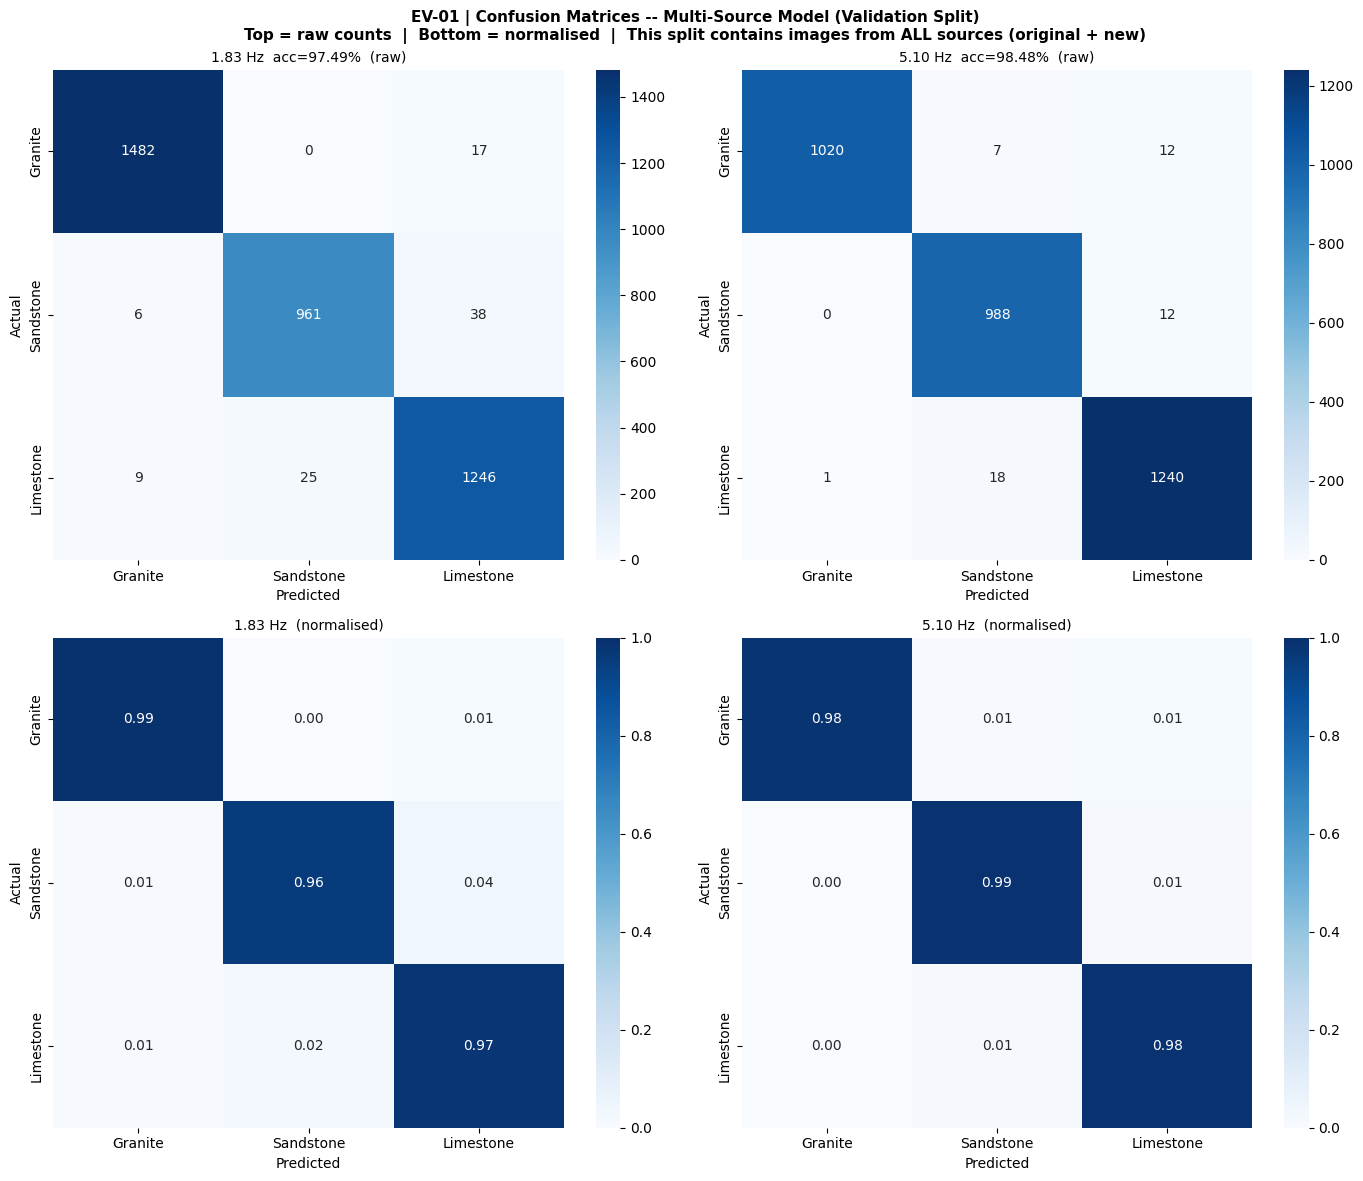

In [123]:
# EV-01  Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14,12))
fig.suptitle(
    'EV-01 | Confusion Matrices -- Multi-Source Model (Validation Split)\n'
    'Top = raw counts  |  Bottom = normalised  |  '
    'This split contains images from ALL sources (original + new)',
    fontsize=11, fontweight='bold')
for col, (tag, preds, labels) in enumerate([
    ('1.83 Hz', pte_183, lte_183),
    ('5.10 Hz', pte_510, lte_510)
]):
    cm   = confusion_matrix(labels, preds)
    cmn  = cm.astype(float)
    rs   = cm.sum(axis=1, keepdims=True)
    np.divide(cmn, rs, out=cmn, where=rs!=0)
    acc  = np.mean(preds==labels)*100
    sns.heatmap(cm,  ax=axes[0][col], annot=True, fmt='d', cmap='Blues',
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    axes[0][col].set_title(f'{tag}  acc={acc:.2f}%  (raw)', fontsize=10)
    axes[0][col].set_ylabel('Actual'); axes[0][col].set_xlabel('Predicted')
    sns.heatmap(cmn, ax=axes[1][col], annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    axes[1][col].set_title(f'{tag}  (normalised)', fontsize=10)
    axes[1][col].set_ylabel('Actual'); axes[1][col].set_xlabel('Predicted')
plt.tight_layout()
save_fig(fig, DIR_EVAL,
    'EV-01_confusion_matrices__multisource.png',
    'Raw and normalised confusion matrices for multi-source model validation split.')
plt.show()

In [124]:
# EV-02  Classification reports
rpts = {}
for tag, preds, labels in [
    ('1-83Hz', pte_183, lte_183),
    ('5-10Hz', pte_510, lte_510)
]:
    rpt_str = classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)
    rpts[tag] = classification_report(labels, preds, target_names=CLASS_NAMES,
                                       output_dict=True, zero_division=0)
    print(f'=== {tag} ===\n{rpt_str}')
    path = os.path.join(DIR_EVAL, f'EV-02_classification_report__{tag}.txt')
    with open(path,'w') as f: f.write(rpt_str)
    _saved_files.append((path, f'Classification report {tag}'))
    print(f'[SAVED] {path}')

=== 1-83Hz ===
                      precision    recall  f1-score   support

          S10Granite     0.9900    0.9887    0.9893      1499
  Holstein_Sandstone     0.9746    0.9562    0.9653      1005
Leitendorf_Limestone     0.9577    0.9734    0.9655      1280

            accuracy                         0.9749      3784
           macro avg     0.9741    0.9728    0.9734      3784
        weighted avg     0.9750    0.9749    0.9749      3784

[SAVED] results_rock_classifier_multisource/evaluation_known_rocks/EV-02_classification_report__1-83Hz.txt
=== 5-10Hz ===
                      precision    recall  f1-score   support

          S10Granite     0.9990    0.9817    0.9903      1039
  Holstein_Sandstone     0.9753    0.9880    0.9816      1000
Leitendorf_Limestone     0.9810    0.9849    0.9830      1259

            accuracy                         0.9848      3298
           macro avg     0.9851    0.9849    0.9850      3298
        weighted avg     0.9850    0.9848    0.9849 

[SAVED] results_rock_classifier_multisource/evaluation_known_rocks/EV-03_perclass_metrics__multisource.png


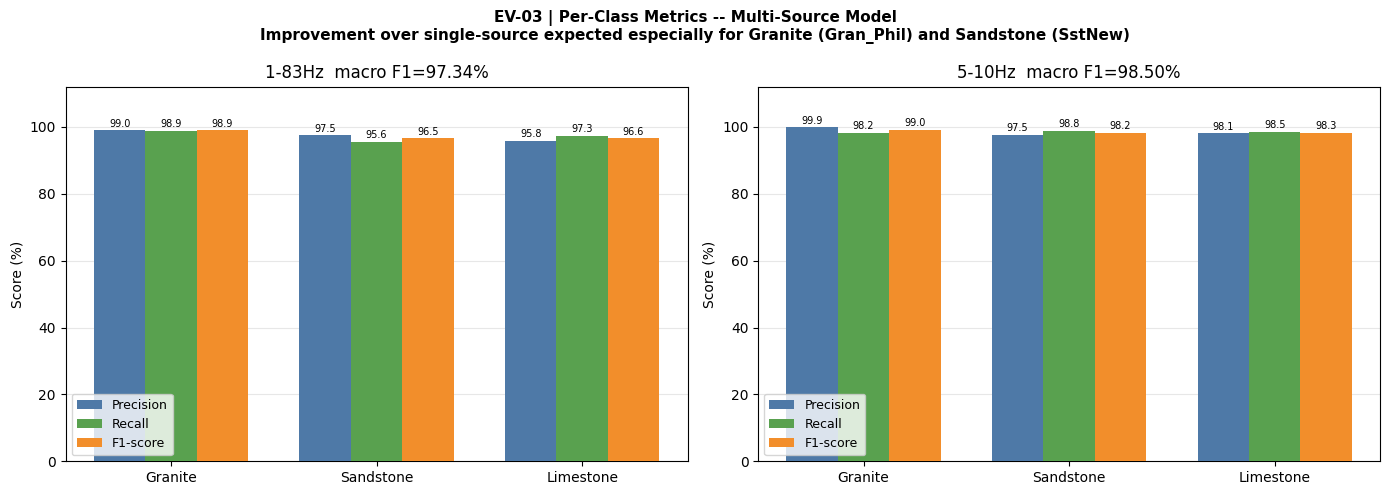

In [125]:
# EV-03  Per-class metrics bar chart
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle(
    'EV-03 | Per-Class Metrics -- Multi-Source Model\n'
    'Improvement over single-source expected especially for Granite (Gran_Phil) '
    'and Sandstone (SstNew)',
    fontsize=11, fontweight='bold')
mc = ['#4e79a7','#59a14f','#f28e2b']
for ax, (tag, rpt) in zip(axes, rpts.items()):
    x = np.arange(len(CLASS_NAMES)); bw = 0.25
    for mi,(met,col) in enumerate(zip(['precision','recall','f1-score'], mc)):
        vals = [rpt[cls][met]*100 for cls in CLASS_NAMES]
        bars = ax.bar(x+(mi-1)*bw, vals, bw, color=col,
                       label=met.capitalize(), zorder=3)
        for b,v in zip(bars,vals):
            ax.text(b.get_x()+b.get_width()/2, v+0.5,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{tag}  macro F1={rpt["macro avg"]["f1-score"]*100:.2f}%')
    ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES)
    ax.set_ylabel('Score (%)'); ax.set_ylim(0,112)
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
save_fig(fig, DIR_EVAL,
    'EV-03_perclass_metrics__multisource.png',
    'Per-class precision, recall, F1 for multi-source model validation split.')
plt.show()

In [126]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1)*1.5)
    def calibrate(self, logits, labels):
        opt  = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        crit = nn.CrossEntropyLoss()
        def step():
            opt.zero_grad()
            loss = crit(logits/self.temperature.clamp(min=0.05), labels)
            loss.backward(); return loss
        opt.step(step)
        self.temperature.data = self.temperature.clamp(min=0.05)
        return self.temperature.item()
    def scale(self, logits):
        return logits/self.temperature.clamp(min=0.05)
    def energy(self, logits):
        return (-self.temperature.item()
                * torch.logsumexp(self.scale(logits),dim=1)).detach().numpy()

scaler_183 = TemperatureScaler()
T_183 = scaler_183.calibrate(logits_183, torch.tensor(lte_183, dtype=torch.long))
scaler_510 = TemperatureScaler()
T_510 = scaler_510.calibrate(logits_510, torch.tensor(lte_510, dtype=torch.long))

energy_val_183 = scaler_183.energy(logits_183)
energy_val_510 = scaler_510.energy(logits_510)

threshold_183 = float(np.percentile(energy_val_183, (1-OOD_FPR)*100))
threshold_510 = float(np.percentile(energy_val_510, (1-OOD_FPR)*100))

print(f'T_183={T_183:.4f}  T_510={T_510:.4f}')
print(f'threshold_183={threshold_183:.4f}  threshold_510={threshold_510:.4f}')
print(f'Actual FPR on val — 1.83Hz: '
      f'{np.mean(energy_val_183>threshold_183)*100:.2f}%  '
      f'5.10Hz: {np.mean(energy_val_510>threshold_510)*100:.2f}%')

T_183=1.2533  T_510=1.4371
threshold_183=-3.3507  threshold_510=-3.9770
Actual FPR on val — 1.83Hz: 5.02%  5.10Hz: 5.00%


[SAVED] results_rock_classifier_multisource/ood_calibration/OOD-01_energy_distribution__multisource_calibration.png


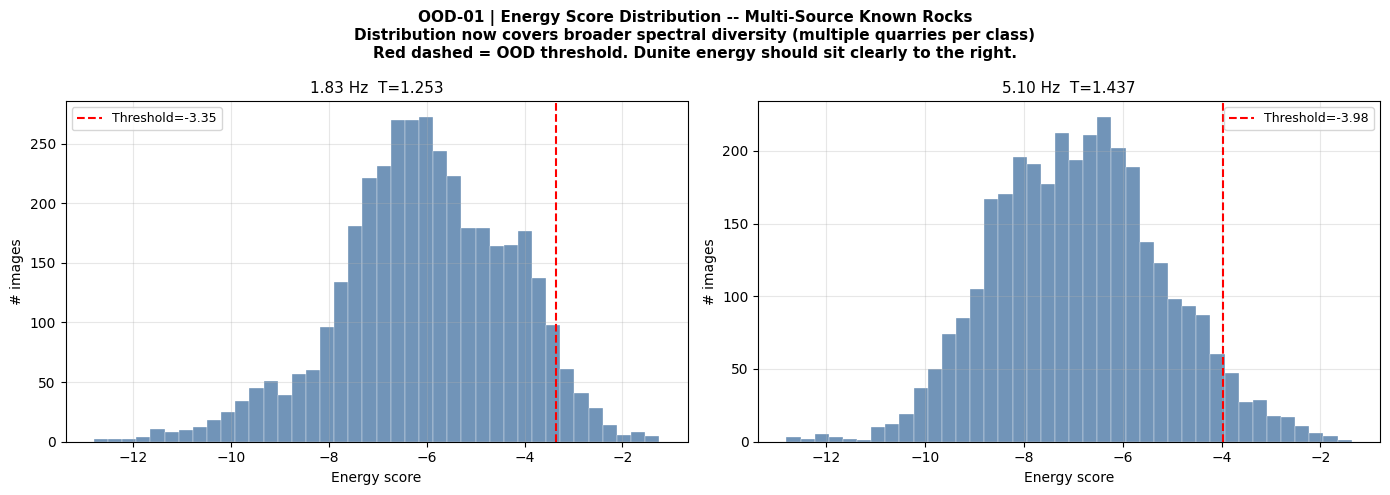

In [127]:
# OOD-01  Energy distribution on known rocks (now multi-source)
fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle(
    'OOD-01 | Energy Score Distribution -- Multi-Source Known Rocks\n'
    'Distribution now covers broader spectral diversity (multiple quarries per class)\n'
    'Red dashed = OOD threshold. Dunite energy should sit clearly to the right.',
    fontsize=11, fontweight='bold')
for ax,(tag,E,thr,T) in zip(axes,[
    ('1.83 Hz',energy_val_183,threshold_183,T_183),
    ('5.10 Hz',energy_val_510,threshold_510,T_510)
]):
    ax.hist(E, bins=40, color='#4e79a7', alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(thr, color='red', ls='--', lw=1.5, label=f'Threshold={thr:.2f}')
    ax.set_title(f'{tag}  T={T:.3f}', fontsize=11)
    ax.set_xlabel('Energy score'); ax.set_ylabel('# images')
    ax.legend(fontsize=9); ax.grid(True,alpha=0.3)
plt.tight_layout()
save_fig(fig, DIR_OOD,
    'OOD-01_energy_distribution__multisource_calibration.png',
    'Energy score histogram on multi-source known-rock validation data. '
    'Broader distribution because multiple quarries per class are now represented.')
plt.show()

In [128]:
# DUNITE OOD TEST
dunite_paths = sorted([
    str(f) for f in Path(OOD_FOLDER).iterdir()
    if f.suffix.lower() in VALID_EXT
])
print(f'Dunite images: {len(dunite_paths)}  (1.83 Hz model)')

# Run inference with OOD detection
def infer_with_ood(model, scaler, threshold, img_paths):
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ds  = UnlabelledDataset(img_paths, eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    results = []
    with torch.no_grad():
        for Xb, fnames in ldr:
            logits   = model(Xb.to(device)).cpu()
            probs    = torch.softmax(scaler.scale(logits),dim=1).numpy()
            energies = scaler.energy(logits)
            for fname, prob, E in zip(fnames, probs, energies):
                pred_idx = int(np.argmax(prob))
                is_ood   = bool(E > threshold)
                results.append({
                    'filename': fname,
                    'pred_class': 'Unknown' if is_ood else CLASS_NAMES[pred_idx],
                    'confidence': float(np.max(prob)),
                    'energy': float(E),
                    'is_ood': is_ood,
                    'probs': prob.tolist(),
                })
    return results

dunite_results = infer_with_ood(model_183, scaler_183, threshold_183, dunite_paths)
n_ood   = sum(1 for r in dunite_results if r['is_ood'])
n_total = len(dunite_results)
mean_e  = np.mean([r['energy'] for r in dunite_results])
mean_c  = np.mean([r['confidence'] for r in dunite_results])
print(f'\nDunite results:')
print(f'  Flagged as Unknown : {n_ood}/{n_total}  ({n_ood/n_total*100:.1f}%)')
print(f'  Mean energy        : {mean_e:.4f}  (threshold: {threshold_183:.4f})')
print(f'  Mean confidence    : {mean_c*100:.1f}%')
verdict = 'CORRECTLY REJECTED as Unknown' if n_ood/n_total > 0.5 else 'MISSED — not flagged as OOD'
print(f'  Verdict            : {verdict}')

Dunite images: 500  (1.83 Hz model)

Dunite results:
  Flagged as Unknown : 17/500  (3.4%)
  Mean energy        : -5.4431  (threshold: -3.3507)
  Mean confidence    : 94.4%
  Verdict            : MISSED — not flagged as OOD


[SAVED] results_rock_classifier_multisource/inference_dunite/INF-01_dunite_ood_test__confidence_and_energy.png


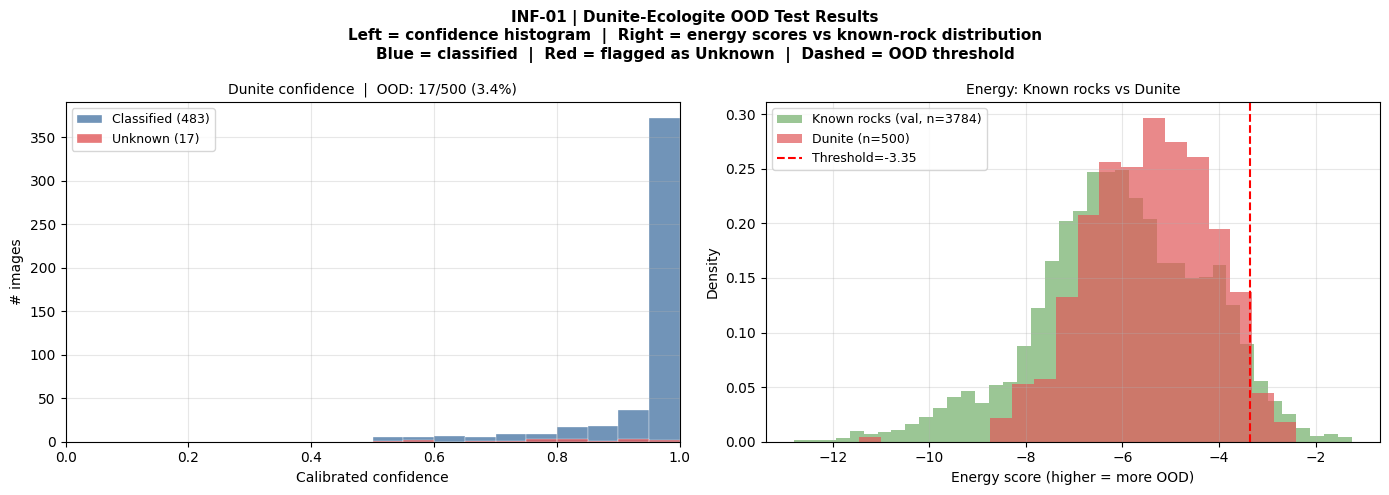

In [ ]:
# INF-01  Dunite confidence histogram vs known-rock distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'INF-01 | Dunite-Ecologite OOD Test Results\n'
    'Left = confidence histogram  |  Right = energy scores vs known-rock distribution\n'
    'Blue = classified  |  Red = flagged as Unknown  |  Dashed = OOD threshold',
    fontsize=11, fontweight='bold')

# Left: confidence histogram
ax = axes[0]
cls_confs = [r['confidence'] for r in dunite_results if not r['is_ood']]
ood_confs = [r['confidence'] for r in dunite_results if r['is_ood']]
if cls_confs:
    ax.hist(cls_confs, bins=20, range=(0,1), color='#4e79a7', alpha=0.8,
            label=f'Classified ({len(cls_confs)})', edgecolor='white', lw=0.3)
if ood_confs:
    ax.hist(ood_confs, bins=20, range=(0,1), color=OOD_COLOR, alpha=0.8,
            label=f'Unknown ({len(ood_confs)})', edgecolor='white', lw=0.3)
ax.set_title(f'Dunite confidence  |  OOD: {n_ood}/{n_total} ({n_ood/n_total*100:.1f}%)',
             fontsize=10)
ax.set_xlabel('Calibrated confidence'); ax.set_ylabel('# images')
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.grid(True, alpha=0.3)

# Right: energy comparison
ax2 = axes[1]
ax2.hist(energy_val_183, bins=40, color='#59a14f', alpha=0.6,
         label=f'Known rocks (val, n={len(energy_val_183)})', density=True)
dunite_energies = [r['energy'] for r in dunite_results]
ax2.hist(dunite_energies, bins=20, color=OOD_COLOR, alpha=0.7,
         label=f'Dunite (n={len(dunite_energies)})', density=True)
ax2.axvline(threshold_183, color='red', ls='--', lw=1.5,
             label=f'Threshold={threshold_183:.2f}')
ax2.set_xlabel('Energy score (higher = more OOD)')
ax2.set_ylabel('Density')
ax2.set_title('Energy: Known rocks vs Dunite', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-01_dunite_ood_test__confidence_and_energy.png',
    'Dunite OOD test: confidence histogram (left) and energy score comparison '
    'vs known rocks (right). Red bars/region = flagged as Unknown.')
plt.show()

Extracting training features...
  S10Granite: 400 samples
  Holstein_Sandstone: 400 samples
  Leitendorf_Limestone: 400 samples
Extracting Dunite features...
  Dunite: 300 samples

Running t-SNE on 1500 samples...
t-SNE done.
[SAVED] results_rock_classifier_multisource/inference_dunite/INF-02_tsne__multisource_training_plus_dunite.png


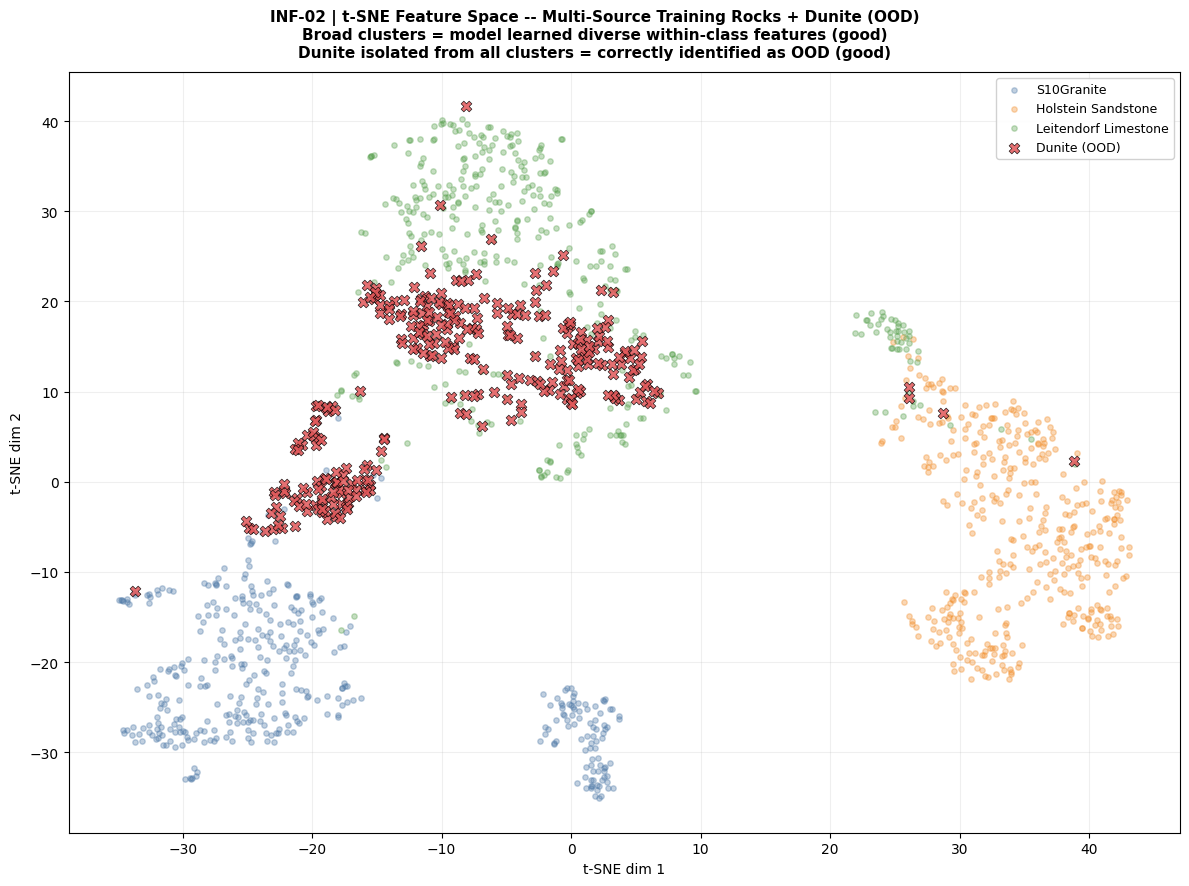

In [130]:
# INF-02  t-SNE: training data + Dunite
def extract_features(model, paths, transform, max_samples=None):
    if max_samples and len(paths) > max_samples:
        idx   = np.random.choice(len(paths), max_samples, replace=False)
        paths = [paths[i] for i in sorted(idx)]
    feats = []
    hook  = model.avgpool.register_forward_hook(
        lambda m,i,o: feats.append(o.squeeze(-1).squeeze(-1).cpu().detach().numpy()))
    ds  = UnlabelledDataset(paths, transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=min(4, os.cpu_count() or 1))
    model.eval()
    with torch.no_grad():
        for Xb,_ in ldr: _ = model(Xb.to(device))
    hook.remove()
    return np.vstack(feats), paths

print('Extracting training features...')
feat_chunks, lbl_chunks = [], []

# Sample from training data (per class, up to 400)
for ci, cls_name in enumerate(CLASS_NAMES):
    cls_paths = [p for p,l in zip(paths_183, labels_183) if l==ci]
    f, _ = extract_features(model_183, cls_paths, eval_transform, max_samples=400)
    feat_chunks.append(f)
    lbl_chunks.extend([cls_name]*len(f))
    print(f'  {cls_name}: {len(f)} samples')

# Dunite features
print('Extracting Dunite features...')
f_dun, _ = extract_features(model_183, dunite_paths, eval_transform, max_samples=300)
feat_chunks.append(f_dun)
lbl_chunks.extend(['Dunite (OOD)']*len(f_dun))
print(f'  Dunite: {len(f_dun)} samples')

X_all   = np.vstack(feat_chunks)
lbl_all = np.array(lbl_chunks)
seed_everything(7)
print(f'\nRunning t-SNE on {X_all.shape[0]} samples...')
tsne_2d = TSNE(n_components=2, perplexity=40, random_state=7,
               max_iter=1000).fit_transform(X_all)
print('t-SNE done.')

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle(
    'INF-02 | t-SNE Feature Space -- Multi-Source Training Rocks + Dunite (OOD)\n'
    'Broad clusters = model learned diverse within-class features (good)\n'
    'Dunite isolated from all clusters = correctly identified as OOD (good)',
    fontsize=11, fontweight='bold')

for cls_name, color in zip(CLASS_NAMES, CLASS_COLORS):
    m = (lbl_all == cls_name)
    ax.scatter(tsne_2d[m,0], tsne_2d[m,1], c=color, s=15, alpha=0.35,
               label=cls_name.replace('_',' '), zorder=2)

m_dun = (lbl_all == 'Dunite (OOD)')
ax.scatter(tsne_2d[m_dun,0], tsne_2d[m_dun,1],
           c=OOD_COLOR, marker='X', s=60, alpha=0.85, zorder=3,
           edgecolors='black', linewidths=0.5, label='Dunite (OOD)')

ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-02_tsne__multisource_training_plus_dunite.png',
    't-SNE projection of multi-source training features + Dunite (OOD). '
    'Broad training clusters show learned spectral diversity. '
    'Dunite should be isolated from all three clusters.')
plt.show()

---
## PHASE 6 — Grad-CAM on Each Class + Dunite

[SAVED] results_rock_classifier_multisource/gradcam/GRADCAM-01_gradcam__multisource_classes_and_dunite.png


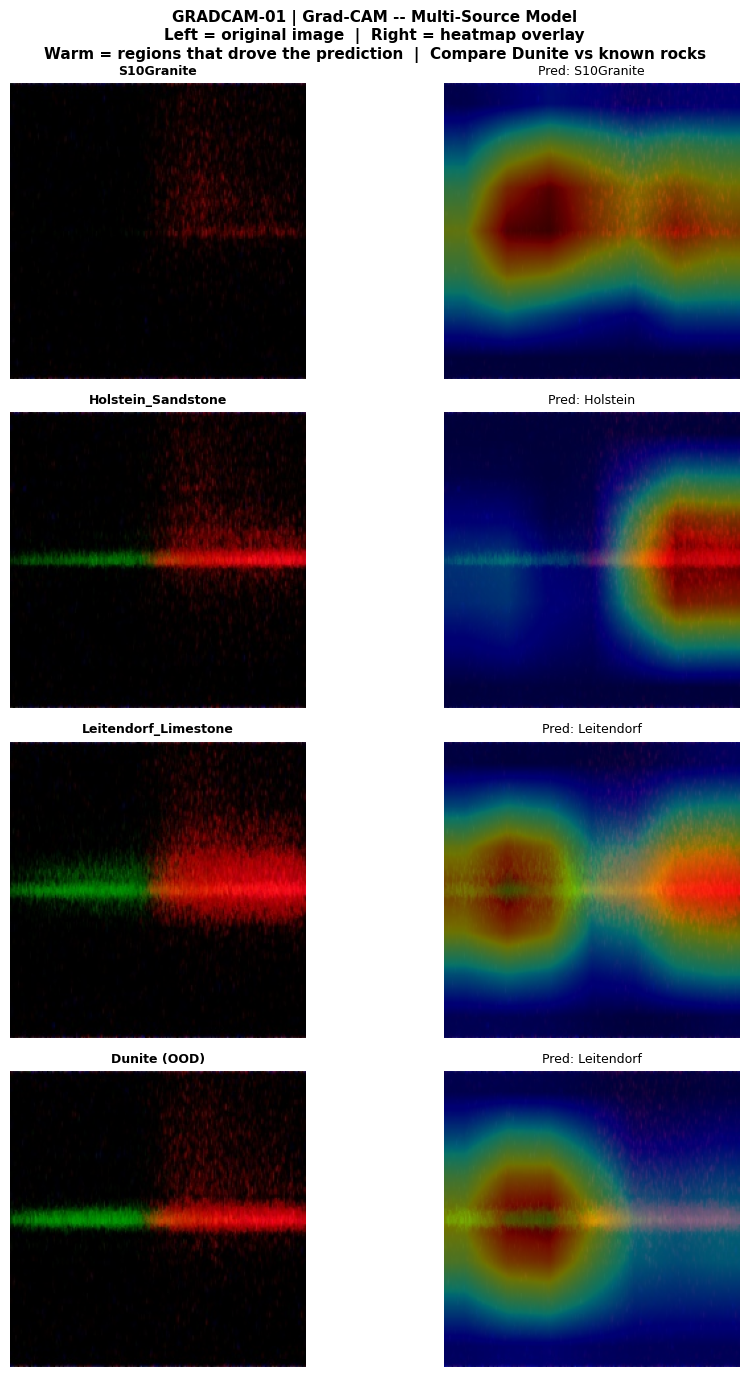

In [131]:
# GRADCAM-01  One sample per class + one Dunite sample
# What it shows: where the multi-source model focuses for each class
# and for Dunite. Compare the Dunite heatmap to the known-rock heatmaps
# to see if the model is focusing on noise vs genuine spectral features.

imagenet_mean_t = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
imagenet_std_t  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
def t2rgb(t): return (t*imagenet_std_t+imagenet_mean_t).clamp(0,1).permute(1,2,0).numpy()

# Pick one sample per class from the validation set + one Dunite
sample_paths = []
sample_labels = []
for ci, cls_name in enumerate(CLASS_NAMES):
    cls_paths_val = [p for p,l in zip(p_te_183, l_te_183) if l==ci]
    sample_paths.append(cls_paths_val[len(cls_paths_val)//2])
    sample_labels.append(cls_name)
sample_paths.append(dunite_paths[len(dunite_paths)//2])
sample_labels.append('Dunite (OOD)')

fig, axes = plt.subplots(len(sample_paths), 2,
                          figsize=(10, 3.5*len(sample_paths)))
fig.suptitle(
    'GRADCAM-01 | Grad-CAM -- Multi-Source Model\n'
    'Left = original image  |  Right = heatmap overlay\n'
    'Warm = regions that drove the prediction  |  '
    'Compare Dunite vs known rocks',
    fontsize=11, fontweight='bold')

for row, (path, lbl) in enumerate(zip(sample_paths, sample_labels)):
    img_t = eval_transform(
        Image.open(path).convert('RGB')).unsqueeze(0).to(device)
    cam_obj = GradCAM(model_183)
    cam, pred_idx = cam_obj.generate(img_t)
    cam_obj.remove()
    img_np  = t2rgb(img_t.squeeze(0).cpu())
    overlay = np.clip(0.55*img_np + 0.45*plt.cm.jet(cam)[...,:3], 0, 1)
    axes[row][0].imshow(img_np); axes[row][0].axis('off')
    axes[row][0].set_title(f'{lbl}', fontsize=9, fontweight='bold')
    axes[row][1].imshow(overlay); axes[row][1].axis('off')
    pred_name = 'Unknown' if lbl=='Dunite (OOD)' and \
                dunite_results[0]['is_ood'] else CLASS_NAMES[pred_idx]
    axes[row][1].set_title(
        f'Pred: {pred_name.split("_")[0]}', fontsize=9)

plt.tight_layout()
save_fig(fig, DIR_CAM,
    'GRADCAM-01_gradcam__multisource_classes_and_dunite.png',
    'Grad-CAM for one sample per class and one Dunite image. '
    'Shows which spectral regions drive predictions in the multi-source model.')
plt.show()

---
## PHASE 7 — Summary & Comparison with Single-Source Model

MULTI-SOURCE MODEL — FINAL SUMMARY
Known rock accuracy (val split):
  1.83 Hz: 97.49%
  5.10 Hz: 98.48%

Dunite OOD detection:
  Flagged as Unknown: 17/500 (3.4%)
  Mean energy: -5.4431  Threshold: -3.3507
  OOD verdict: FAIL

Training data composition (1.83 Hz):
  S10Granite: 5993 images from 4 source(s)
  Holstein_Sandstone: 4021 images from 2 source(s)
  Leitendorf_Limestone: 5121 images from 4 source(s)
[SAVED] results_rock_classifier_multisource/comparison/CMP-01_multisource_summary__accuracy_and_ood.png


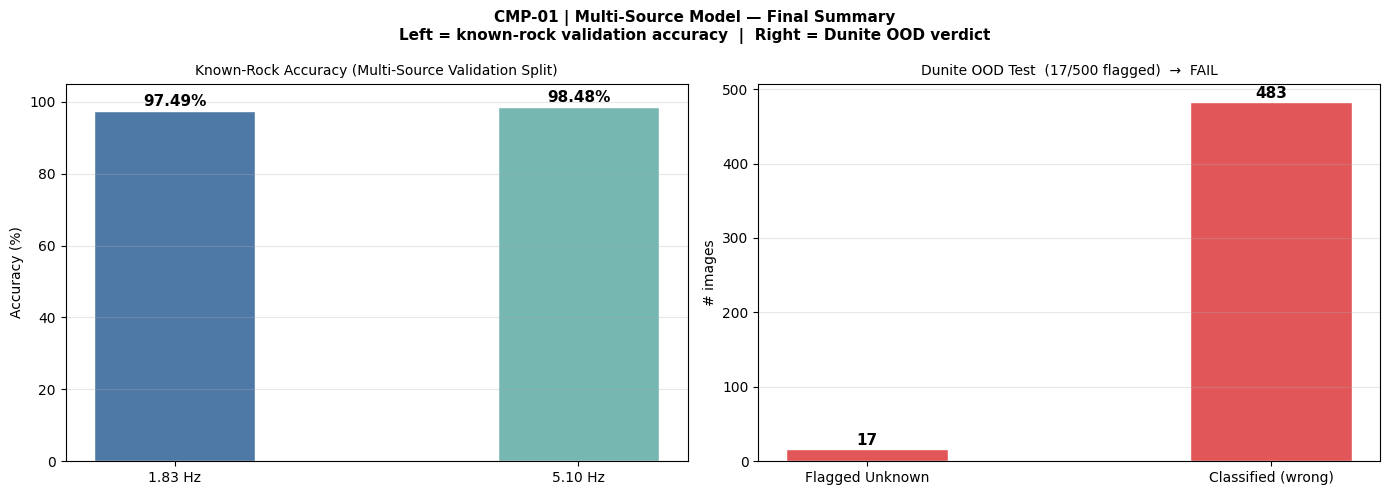

In [ ]:
# CMP-01  Final summary
n_dun_ood   = sum(1 for r in dunite_results if r['is_ood'])
n_dun_total = len(dunite_results)
acc_183     = np.mean(pte_183==lte_183)*100
acc_510     = np.mean(pte_510==lte_510)*100

print('='*70)
print('MULTI-SOURCE MODEL — FINAL SUMMARY')
print('='*70)
print(f'Known rock accuracy (val split):')
print(f'  1.83 Hz: {acc_183:.2f}%')
print(f'  5.10 Hz: {acc_510:.2f}%')
print(f'\nDunite OOD detection:')
print(f'  Flagged as Unknown: {n_dun_ood}/{n_dun_total} ({n_dun_ood/n_dun_total*100:.1f}%)')
print(f'  Mean energy: {mean_e:.4f}  Threshold: {threshold_183:.4f}')
dun_verdict = 'PASS' if n_dun_ood/n_dun_total > 0.5 else 'FAIL'
print(f'  OOD verdict: {dun_verdict}')
print(f'\nTraining data composition (1.83 Hz):')
for ci, cls_name in enumerate(CLASS_NAMES):
    n = sum(1 for l in labels_183 if l==ci)
    print(f'  {cls_name}: {n} images from '
          f'{len(sources_183[cls_name])} source(s)')
print('='*70)

# ── Figure saved to comparison/
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'CMP-01 | Multi-Source Model — Final Summary\n'
    'Left = known-rock validation accuracy  |  Right = Dunite OOD verdict',
    fontsize=11, fontweight='bold')

ax = axes[0]
bars = ax.bar(['1.83 Hz', '5.10 Hz'], [acc_183, acc_510],
              color=['#4e79a7', '#76b7b2'], width=0.4, edgecolor='white')
for b, v in zip(bars, [acc_183, acc_510]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
ax.set_title('Known-Rock Accuracy (Multi-Source Validation Split)', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
n_classified = n_dun_total - n_dun_ood
bar_color    = '#59a14f' if dun_verdict == 'PASS' else '#e15759'
ax2.bar(['Flagged Unknown', 'Classified (wrong)'],
        [n_dun_ood, n_classified],
        color=[bar_color, '#e15759'], width=0.4, edgecolor='white')
for xi, v in enumerate([n_dun_ood, n_classified]):
    ax2.text(xi, v + 0.3, str(v), ha='center', va='bottom',
             fontsize=11, fontweight='bold')
ax2.set_ylabel('# images')
ax2.set_title(
    f'Dunite OOD Test  ({n_dun_ood}/{n_dun_total} flagged)  →  {dun_verdict}',
    fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_CMP,
    'CMP-01_multisource_summary__accuracy_and_ood.png',
    'Multi-source model summary: known-rock validation accuracy and Dunite OOD verdict.')
plt.show()




NOTE: Before/After comparison uses the old single-source model results.
The multi-source model was trained on all folders EXCEPT Dunite,
so the other folders are now training data — not fair test cases.
Dunite remains the only fair OOD test.

Folder               Expected     Old pred      Old conf   Old  New pred        New OOD%   New
------------------------------------------------------------------------------------------
Dun-Eco              Unknown      Limestone        97.5%  ❌  Leitendorf_Limestone      3.4%  ❌
Gneis                Granite      Granite          96.5%  ✅  Training data          —  ✅
Gran_Phil_1          Granite      Limestone        99.8%  ❌  Training data          —  ✅
Gran_Phil_2          Granite      Limestone        99.7%  ❌  Training data          —  ✅
CalcSil_183          Limestone    Sandstone        98.6%  ❌  Training data          —  ✅
CalcSil_510          Limestone    Sandstone        97.4%  ❌  Training data          —  ✅
Lst_Rax_1            Limestone

[SAVED] results_rock_classifier_multisource/comparison/CMP-02_before_after__single_vs_multisource.png


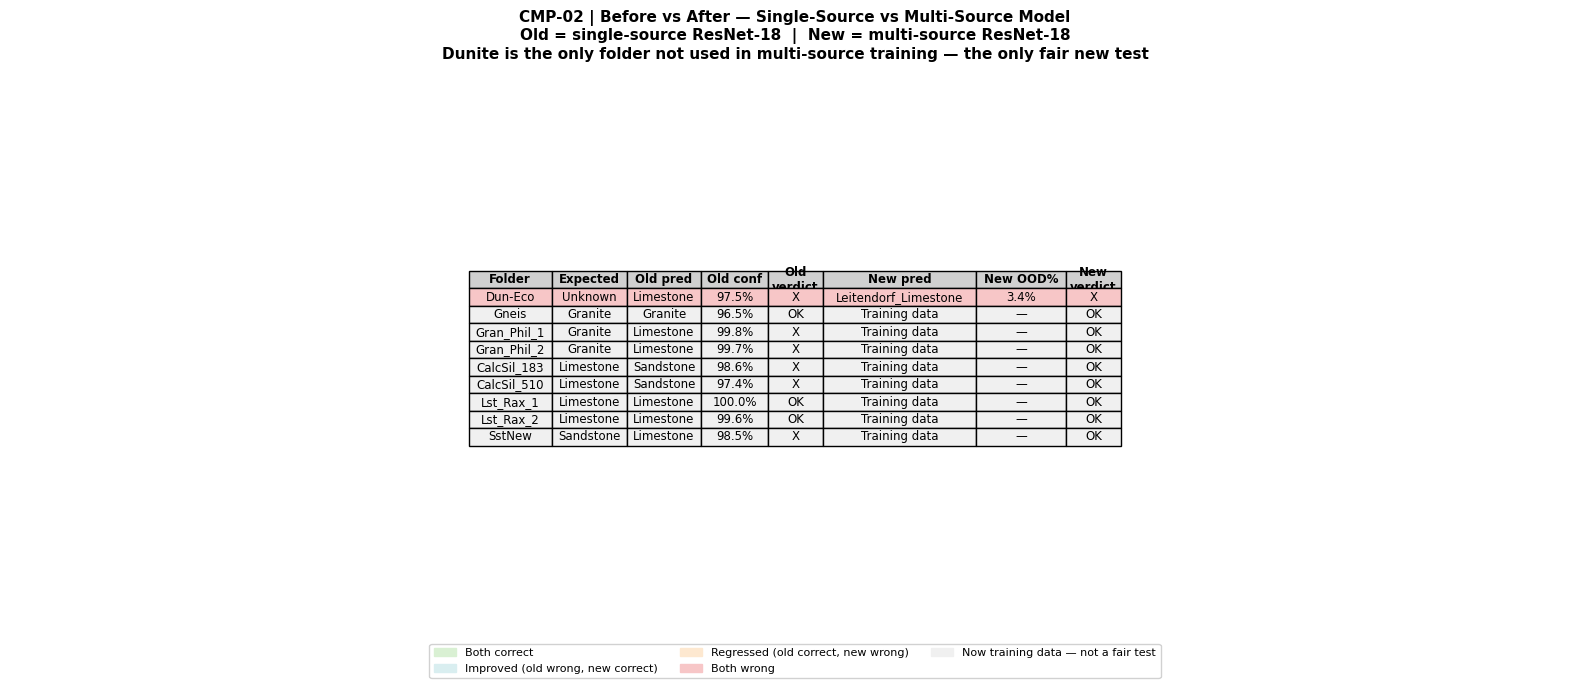

In [ ]:
# CMP-02  Before/after comparison table
single_source_results = {
    'Dun-Eco'    : {'old_pred':'Limestone', 'old_conf':97.5, 'old_ood_pct':4.6,
                    'expected':'Unknown'},
    'Gneis'      : {'old_pred':'Granite',   'old_conf':96.5, 'old_ood_pct':6.2,
                    'expected':'Granite'},
    'Gran_Phil_1': {'old_pred':'Limestone', 'old_conf':99.8, 'old_ood_pct':0.2,
                    'expected':'Granite'},
    'Gran_Phil_2': {'old_pred':'Limestone', 'old_conf':99.7, 'old_ood_pct':0.2,
                    'expected':'Granite'},
    'CalcSil_183': {'old_pred':'Sandstone', 'old_conf':98.6, 'old_ood_pct':2.8,
                    'expected':'Limestone'},
    'CalcSil_510': {'old_pred':'Sandstone', 'old_conf':97.4, 'old_ood_pct':4.6,
                    'expected':'Limestone'},
    'Lst_Rax_1'  : {'old_pred':'Limestone', 'old_conf':100.0,'old_ood_pct':0.0,
                    'expected':'Limestone'},
    'Lst_Rax_2'  : {'old_pred':'Limestone', 'old_conf':99.6, 'old_ood_pct':0.0,
                    'expected':'Limestone'},
    'SstNew'     : {'old_pred':'Limestone', 'old_conf':98.5, 'old_ood_pct':0.0,
                    'expected':'Sandstone'},
}

# New model result — only Dunite is a fair test; all others are now training data
dun_top = 'Unknown' if n_dun_ood / n_dun_total > 0.5 else CLASS_NAMES[
    int(np.bincount([r['pred_class'] != 'Unknown' and
                     CLASS_NAMES.index(r['pred_class'])
                     for r in dunite_results
                     if not r['is_ood']] or [0]).argmax())]
new_model_col = {
    name: ('Unknown' if name == 'Dun-Eco' and n_dun_ood / n_dun_total > 0.5
           else dun_top  if name == 'Dun-Eco'
           else 'Training data')
    for name in single_source_results
}
new_ood_col = {
    name: (f'{n_dun_ood / n_dun_total * 100:.1f}%' if name == 'Dun-Eco'
           else '—')
    for name in single_source_results
}

print('\nNOTE: Before/After comparison uses the old single-source model results.')
print('The multi-source model was trained on all folders EXCEPT Dunite,')
print('so the other folders are now training data — not fair test cases.')
print('Dunite remains the only fair OOD test.\n')

header = f"{'Folder':<20} {'Expected':<12} {'Old pred':<12} {'Old conf':>9}  {'Old':>4}  {'New pred':<14} {'New OOD%':>9}  {'New':>4}"
print(header)
print('-' * 90)
for name, d in single_source_results.items():
    old_ok = (d['old_pred'].lower() in d['expected'].lower() or
              (d['expected'] == 'Unknown' and d['old_ood_pct'] > 50))
    new_pred = new_model_col[name]
    new_ok = (new_pred == 'Training data' or
              new_pred.lower() in d['expected'].lower() or
              (d['expected'] == 'Unknown' and new_pred == 'Unknown'))
    old_icon = '\u2705' if old_ok else '\u274c'
    new_icon = '\u2705' if new_ok else '\u274c'
    print(f"{name:<20} {d['expected']:<12} {d['old_pred']:<12} "
          f"{d['old_conf']:>8.1f}%  {old_icon}  "
          f"{new_pred:<14} {new_ood_col[name]:>9}  {new_icon}")
print('=' * 90)

# ── Figure saved to comparison/ 
fig, ax = plt.subplots(figsize=(16, max(4, len(single_source_results) * 0.55 + 2)))
fig.suptitle(
    'CMP-02 | Before vs After — Single-Source vs Multi-Source Model\n'
    'Old = single-source ResNet-18  |  New = multi-source ResNet-18\n'
    'Dunite is the only folder not used in multi-source training — the only fair new test',
    fontsize=11, fontweight='bold')
ax.axis('off')

col_labels = ['Folder', 'Expected', 'Old pred', 'Old conf', 'Old\nverdict',
              'New pred', 'New OOD%', 'New\nverdict']
table_data = []
row_colors = []
for name, d in single_source_results.items():
    old_ok = (d['old_pred'].lower() in d['expected'].lower() or
              (d['expected'] == 'Unknown' and d['old_ood_pct'] > 50))
    new_pred = new_model_col[name]
    new_ok = (new_pred == 'Training data' or
              new_pred.lower() in d['expected'].lower() or
              (d['expected'] == 'Unknown' and new_pred == 'Unknown'))
    old_icon = 'OK' if old_ok else 'X'
    new_icon = 'OK' if new_ok else 'X'
    table_data.append([
        name, d['expected'], d['old_pred'],
        f"{d['old_conf']:.1f}%", old_icon,
        new_pred, new_ood_col[name], new_icon
    ])
    if new_pred == 'Training data':
        row_colors.append(['#f0f0f0'] * 8)
    elif new_ok and old_ok:
        row_colors.append(['#d9f0d3'] * 8)   # both correct — green
    elif new_ok and not old_ok:
        row_colors.append(['#d9eef0'] * 8)   # improved — blue
    elif not new_ok and old_ok:
        row_colors.append(['#fde8d0'] * 8)   # regressed — orange
    else:
        row_colors.append(['#f7c6c7'] * 8)   # both wrong — red

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center', loc='center',
    cellColours=row_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.auto_set_column_width(list(range(len(col_labels))))
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#d0d0d0')
    tbl[0, j].set_text_props(fontweight='bold')

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#d9f0d3', label='Both correct'),
    mpatches.Patch(color='#d9eef0', label='Improved (old wrong, new correct)'),
    mpatches.Patch(color='#fde8d0', label='Regressed (old correct, new wrong)'),
    mpatches.Patch(color='#f7c6c7', label='Both wrong'),
    mpatches.Patch(color='#f0f0f0', label='Now training data — not a fair test'),
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8, framealpha=0.9)

plt.tight_layout()
save_fig(fig, DIR_CMP,
    'CMP-02_before_after__single_vs_multisource.png',
    'Before/after comparison table: single-source vs multi-source model per folder.')
plt.show()



---
## Save CSVs & Results Index

In [134]:
# SAVE DUNITE PREDICTIONS CSV
csv_dun = os.path.join(RESULTS_DIR, 'predictions_dunite_ood_test.csv')
with open(csv_dun,'w',newline='') as f:
    w = csv.writer(f)
    w.writerow(['filename','predicted_class','confidence','energy','is_ood',
                'prob_S10Granite','prob_Holstein_Sandstone',
                'prob_Leitendorf_Limestone'])
    for r in dunite_results:
        w.writerow([r['filename'],r['pred_class'],
                    round(r['confidence'],4),round(r['energy'],4),r['is_ood'],
                    round(r['probs'][0],4),round(r['probs'][1],4),
                    round(r['probs'][2],4)])
_saved_files.append((csv_dun, 'Dunite OOD test predictions per image'))
print(f'[SAVED] {csv_dun}')

# SAVE EVALUATION CSV
csv_eval = os.path.join(RESULTS_DIR, 'evaluation_known_rocks_multisource.csv')
with open(csv_eval,'w',newline='') as f:
    w = csv.writer(f)
    w.writerow(['speed','class','precision','recall','f1_score','support'])
    for tag, rpt in rpts.items():
        for cls in CLASS_NAMES:
            w.writerow([tag,cls,
                        round(rpt[cls]['precision'],4),
                        round(rpt[cls]['recall'],4),
                        round(rpt[cls]['f1-score'],4),
                        int(rpt[cls]['support'])])
_saved_files.append((csv_eval, 'Per-class metrics on multi-source validation split'))
print(f'[SAVED] {csv_eval}')

[SAVED] results_rock_classifier_multisource/predictions_dunite_ood_test.csv
[SAVED] results_rock_classifier_multisource/evaluation_known_rocks_multisource.csv


In [135]:
# RESULTS INDEX
index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
folder_map = {
    'training':               'PHASE 1 -- Train & Save',
    'evaluation_known_rocks': 'PHASE 2 -- Known Rock Evaluation',
    'ood_calibration':        'PHASE 3 -- OOD Calibration',
    'inference_dunite':       'PHASE 4+5 -- Dunite OOD Test & t-SNE',
    'gradcam':                'PHASE 6 -- Grad-CAM',
    'comparison':             'PHASE 7 -- Summary',
    '(root)':                 'ROOT FILES',
}
groups = {k: [] for k in folder_map}
for path, desc in _saved_files:
    placed = False
    for key in list(folder_map.keys())[:-1]:
        if key in path: groups[key].append((path,desc)); placed=True; break
    if not placed: groups['(root)'].append((path,desc))

with open(index_path,'w') as f:
    f.write('RESULTS INDEX -- rock_classifier_multisource\n')
    f.write('='*80+'\n')
    f.write(f'ARCH={ARCH}  USE_STRONG_AUG={USE_STRONG_AUG}  '
            f'FREEZE_BACKBONE={FREEZE_BACKBONE}\n')
    f.write(f'EPOCHS={EPOCHS}  LR={LR}  TEST_SPLIT={TEST_SPLIT}  '
            f'OOD_FPR={OOD_FPR}\n')
    f.write(f'T_183={T_183:.4f}  T_510={T_510:.4f}\n')
    f.write(f'threshold_183={threshold_183:.4f}  '
            f'threshold_510={threshold_510:.4f}\n')
    f.write(f'Dunite OOD: {n_dun_ood}/{n_dun_total} flagged Unknown\n')
    f.write('='*80+'\n\n')
    for key, entries in groups.items():
        if not entries: continue
        f.write(folder_map[key]+'\n'+'-'*80+'\n')
        for path, desc in entries:
            f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')
        f.write('\n')
print(f'[SAVED] {index_path}')
print(f'Total files: {len(_saved_files)}')
with open(index_path) as f: print('\n'+f.read())

[SAVED] results_rock_classifier_multisource/RESULTS_INDEX.txt
Total files: 13

RESULTS INDEX -- rock_classifier_multisource
ARCH=resnet18  USE_STRONG_AUG=True  FREEZE_BACKBONE=False
EPOCHS=20  LR=0.0001  TEST_SPLIT=0.25  OOD_FPR=0.05
T_183=1.2533  T_510=1.4371
threshold_183=-3.3507  threshold_510=-3.9770
Dunite OOD: 17/500 flagged Unknown

PHASE 1 -- Train & Save
--------------------------------------------------------------------------------
  TR-00_dataset_composition__multisource.png
    Training dataset composition by source folder for each class. Shows original vs new sources and image counts per class.

  INF-02_tsne__multisource_training_plus_dunite.png
    t-SNE projection of multi-source training features + Dunite (OOD). Broad training clusters show learned spectral diversity. Dunite should be isolated from all three clusters.


PHASE 2 -- Known Rock Evaluation
--------------------------------------------------------------------------------
  EV-01_confusion_matrices__multisou